# Chapter 11. BERT Binary 방식 B — softmax + CrossEntropyLoss

**목표**: Ch 10에서 본 *방식 A* (sigmoid + BCE, `num_labels=1`)와 짝을 이루는 **방식 B** (softmax + CE, `num_labels=2`)를 같은 BERT·같은 Yelp 이진화 데이터로 학습합니다. 마지막에 두 방식의 결과를 **직접 비교** 해서 Ch 4(sklearn)에서 식으로 봤던 *두 방식 동등성* 이 BERT에서도 그대로 성립함을 확인합니다.

**환경**: Google Colab **T4 GPU 필수**.

**예상 소요 시간**: 약 20분 (방식 B 학습 ~8분 + 방식 A 비교용 학습 ~8분 + 평가/시각화/비교)

---

## 학습 흐름

1. 🚀 **실습**: Ch 10과 같은 데이터를 BERT로 다시 학습 — 이번엔 `num_labels=2` + softmax + `CrossEntropyLoss`
2. 🔬 **해부**: 학습 후 softmax 확률 분포를 sigmoid (방식 A) 와 같은 KDE 그림으로 비교. logit 공간에서는 $z = z_1 - z_0$ 으로 변환.
3. 🛠️ **클라이맥스**: *이 노트북 안에서* 방식 A도 한 번 더 학습한 뒤 *샘플 단위로* 비교 — scatter plot과 agreement metric. 노트북이 self-contained라 Ch 10 세션이 살아 있을 필요가 없습니다.

---

> 📒 **사전 학습 자료**: Ch 4 (sklearn 두 방식 동등성), Ch 10 (BERT 방식 A — 방식 A의 단독 학습/시각화는 거기서 자세히). 이번 챕터는 Ch 10에 *의존하지 않습니다* — 5장 비교를 위해 같은 노트북 안에서 방식 A를 한 번 더 학습합니다.

## 📊 변화추적표

| Ch | 모델 | 토크나이저 | 데이터 | Output Head | Activation | Loss |
|---|---|---|---|---|---|---|
| 3 | `LogisticRegression()` | `TfidfVectorizer()` | Yelp 이진화 | (1차원) | sigmoid | `BCEWithLogitsLoss` |
| 4 | `LogisticRegression()` (multinomial 자동) | `TfidfVectorizer()` | Yelp 이진화 (Ch 3과 동일) | (2차원) | softmax | `CrossEntropyLoss` |
| 9 | DistilBERT 파인튜닝 | `AutoTokenizer.from_pretrained(...)` | Yelp (별점 1-5) | `Linear(H, 1)` | 없음 | `MSELoss` |
| 10 | DistilBERT 파인튜닝 | 같음 | Yelp 이진화 | `Linear(H, 1)` | sigmoid | `BCEWithLogitsLoss` |
| **11 ← 여기** | DistilBERT 파인튜닝 | 같음 | Yelp 이진화 (Ch 10과 동일) | **`Linear(H, 2)`** | **softmax** | **`CrossEntropyLoss`** |
| 12 (다음) | DistilBERT 파인튜닝 | 같음 | Yelp 5클래스 | `Linear(H, 5)` | softmax | `CrossEntropyLoss` |

전체 20챕터 표는 [루트 README.md](https://github.com/yoon-gu/neuqes-101#챕터별-변화추적표)를 참고하세요.

## 🔄 변경점 (Diff from Ch 10)

| 축 | Ch 10 (방식 A) | Ch 11 (방식 B) |
|---|---|---|
| `num_labels` | 1 | **2** |
| `problem_type` | `"multi_label_classification"` | **`"single_label_classification"`** ← BERT 표준 분류 |
| Activation | sigmoid | **softmax** |
| Loss | `BCEWithLogitsLoss` | **`CrossEntropyLoss`** |
| 라벨 형식 | float `[0.0]` / `[1.0]` (multi-hot 1차원) | **int `0` / `1`** (스칼라 인덱스) |
| 모델 출력 shape | `(B, 1)` | **`(B, 2)`** |
| 데이터 / 모델 본체 / hyperparams | (변동 없음) | (그대로) |

> **딱 하나의 축만 바뀝니다** — 이번 챕터에서 변하는 건 *Loss 축* (BCE → CE)이고, 그에 따라가는 부수적 변화(num_labels, activation, 라벨 형식)는 모두 *같은 축의 일관된 표현 변경* 입니다. 데이터·모델·학습 hyperparams는 Ch 10과 *완전히 동일* 하게 유지해야 마지막 비교가 의미가 있습니다.

### 왜 두 방식이 거의 같은 결과를 내야 하는가 (수식 한 줄)

방식 A의 확률: $\hat p_A = \sigma(z)$ — *1차원 logit* $z$.

방식 B의 확률: $\hat p_B = \mathrm{softmax}(z_0, z_1)[1] = \dfrac{e^{z_1}}{e^{z_0} + e^{z_1}} = \dfrac{1}{1 + e^{-(z_1 - z_0)}} = \sigma(z_1 - z_0)$.

→ **$z_A \equiv z_1 - z_0$** 으로 두면 두 방식이 수학적으로 같은 함수입니다. 학습된 가중치는 다른 경로로 수렴하지만, *최종 확률* 은 거의 같아야 합니다 (Ch 4에서 sklearn으로 봤던 그 동등성).

## 📐 Loss 노트 — `CrossEntropyLoss` (Ch 4 그대로, BERT 맥락)

$$L = -\frac{1}{N}\sum_{i=1}^{N}\log \hat p_{i, y_i} \quad\text{where}\quad \hat p_{i,k} = \dfrac{e^{z_{i,k}}}{\sum_{j} e^{z_{i,j}}}$$

이번 챕터에서 새로운 점은 없고 — Ch 4·5에서 이미 다 익혔습니다. *BERT* 라는 컨텍스트로 옮겨 쓸 뿐입니다.

**숫자로 감 잡기 (binary, K=2)** — 정답이 클래스 1, logits를 $(z_0, z_1)$ 로 두면:

| logits $(z_0, z_1)$ | softmax → $(p_0, p_1)$ | 정답=1일 때 손실 $-\log p_1$ |
|---|---|---|
| $(0, 0)$ | $(0.5, 0.5)$ | 0.693 |
| $(0, 2)$ | $(0.119, 0.881)$ | 0.127 |
| $(0, 5)$ | $(0.007, 0.993)$ | 0.007 |
| $(0, -2)$ | $(0.881, 0.119)$ | **2.127** |

$z_1 - z_0$ 의 크기가 정답 클래스 쪽으로 클수록 손실이 작아집니다. **방식 A의 $z$ 와 정확히 같은 신호**: $\sigma(z_1 - z_0) = p_1$ 가 1에 가까우면 손실이 작음.

**`CrossEntropyLoss` 의 안정성** — PyTorch `nn.CrossEntropyLoss` 는 내부적으로 *log-softmax + NLL* 로 구현되어 있어 `BCEWithLogitsLoss` 와 동일하게 **logit에서 직접 계산** (softmax를 따로 적용하지 않음). 두 loss 모두 "raw logit 받아서 안정적인 log-sum-exp 트릭으로 처리" 라는 점이 같습니다.

## 🔤 토크나이저 노트

Ch 10과 동일한 `distilbert-base-uncased` WordPiece 토크나이저, 동일한 max_length=128. 토크나이저 단계는 그대로지만 **`tokenize_fn` 안에서 라벨을 `[float(b)]` 가 아닌 `int(b)` 로 둡니다** — 이게 이번 챕터의 데이터 측 유일한 변경.

In [1]:
!pip install -q transformers datasets

In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from datasets import load_dataset
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    Trainer, TrainingArguments,
)
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    classification_report, roc_auc_score,
)

plt.rcParams["axes.unicode_minus"] = False

print(f"PyTorch:        {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU:             {torch.cuda.get_device_name(0)}")
else:
    print("Warning: CPU runtime — training will be very slow. Switch to T4 recommended.")

PyTorch:        2.11.0+cu128
CUDA available: True
GPU:             Tesla T4


**baseline VRAM**:

In [3]:
!nvidia-smi

Wed Jun 17 21:34:39 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   41C    P8             11W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## 1. 🚀 데이터 — Yelp 이진화 (Ch 10과 정확히 동일)

같은 seed, 같은 5,000/1,000 샘플, 같은 별점 3 제외 + 4-5 → 1, 1-2 → 0 룰. **마지막 비교가 의미를 가지려면 데이터가 동일해야 합니다.**

In [4]:
tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

ds = load_dataset("Yelp/yelp_review_full")
train_full = ds["train"].shuffle(seed=42).select(range(5000))
eval_full  = ds["test"].shuffle(seed=42).select(range(1000))

# 별점 3 제외 + 이진화
def add_binary(batch):
    bins = []
    for lbl in batch["label"]:
        star = lbl + 1
        bins.append(1 if star >= 4 else 0)   # ← Ch 10과 다른 점: int (스칼라)
    batch["binary"] = bins
    return batch

train_bin = train_full.filter(lambda x: (x["label"] + 1) != 3).map(add_binary, batched=True)
eval_bin  = eval_full.filter(lambda x:  (x["label"] + 1) != 3).map(add_binary, batched=True)

print(f"train (after excluding 3-star): {len(train_bin)}")
print(f"eval  (after excluding 3-star): {len(eval_bin)}")
print(f"train positive rate: {sum(train_bin['binary']) / len(train_bin):.1%}")

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

README.md:   0%|          | 0.00/6.72k [00:00<?, ?B/s]

...

Filter:   0%|          | 0/5000 [00:00<?, ? examples/s]

Map:   0%|          | 0/4040 [00:00<?, ? examples/s]

Filter:   0%|          | 0/1000 [00:00<?, ? examples/s]

Map:   0%|          | 0/804 [00:00<?, ? examples/s]

train (after excluding 3-star): 4040
eval  (after excluding 3-star): 804
train positive rate: 49.4%


**Ch 10과의 한 줄 차이**: `out["labels"] = [[float(b)] for b in batch["binary"]]` → `out["labels"] = [int(b) for b in batch["binary"]]`. 라벨이 *길이 1짜리 float 리스트* 가 아니라 *int 스칼라* 입니다.

In [5]:
def tokenize_fn(batch):
    out = tokenizer(batch["text"], truncation=True, max_length=128)
    out["labels"] = [int(b) for b in batch["binary"]]   # ← int 스칼라 (Ch 10은 [float(b)])
    return out

train_tok = train_bin.map(tokenize_fn, batched=True).remove_columns(["text", "label", "binary"])
eval_tok  = eval_bin.map(tokenize_fn,  batched=True).remove_columns(["text", "label", "binary"])

print(train_tok)
print(f"\nFirst sample label: {train_tok[0]['labels']}  (int scalar)")

Map:   0%|          | 0/4040 [00:00<?, ? examples/s]

Map:   0%|          | 0/804 [00:00<?, ? examples/s]

Dataset({
    features: ['input_ids', 'token_type_ids', 'attention_mask', 'labels'],
    num_rows: 4040
})

First sample label: 1  (int scalar)


## 2. 모델 로드 — 방식 B 셋업

`num_labels=2` + `problem_type="single_label_classification"` (BERT 분류의 *기본값*).

In [6]:
model = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=2,
    problem_type="single_label_classification",   # ← CrossEntropyLoss 자동 매핑 (BERT 분류 표준)
    id2label={0: "negative", 1: "positive"},
    label2id={"negative": 0, "positive": 1},
)

def param_summary(m):
    total     = sum(p.numel() for p in m.parameters())
    trainable = sum(p.numel() for p in m.parameters() if p.requires_grad)
    return total, trainable

total, trainable = param_summary(model)
print(f"Parameters:           {total:>13,}  ({total/1e6:.1f} M)")
print(f"Trainable parameters: {trainable:>13,}  ({trainable/total:.1%})")
print(f"Classifier:           {model.classifier}")
print(f"problem_type:         {model.config.problem_type}")
print(f"id2label:             {model.config.id2label}")

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Parameters:              66,955,010  (67.0 M)
Trainable parameters:    66,955,010  (100.0%)
Classifier:           Linear(in_features=768, out_features=2, bias=True)
problem_type:         single_label_classification
id2label:             {0: 'negative', 1: 'positive'}


**파라미터 수 비교 — 방식 A vs 방식 B**

| 부분 | 방식 A (`num_labels=1`) | 방식 B (`num_labels=2`) |
|---|---|---|
| DistilBERT body | 66,362,880 | 66,362,880 |
| pre_classifier (`Linear(768→768)`) | 590,592 | 590,592 |
| classifier (`Linear(768→K)`) | **769** (=768+1) | **1,538** (=768·2+2) |
| 합계 | 66,955,010 | 66,955,778 |

방식 B의 분류 헤드 파라미터가 정확히 *2배* 입니다. 차이는 **769개** — 전체 67M 중 0.001%. 이 미세한 자유도 차이가 두 방식의 *최종 확률* 을 거의 같게, *학습된 가중치* 는 미묘하게 다르게 만듭니다.

In [7]:
!nvidia-smi

Wed Jun 17 21:35:05 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   42C    P8             14W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## 3. 학습 — Ch 10과 동일한 hyperparams

Ch 10과 *완전히 같은* learning rate, batch size, epoch 수, seed. **변하는 건 모델 출력 shape와 loss 종류뿐**.

In [8]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    # logits.shape = (B, 2)  → softmax → 클래스 1 확률
    exp = np.exp(logits - logits.max(axis=1, keepdims=True))   # 안정화
    probs_full = exp / exp.sum(axis=1, keepdims=True)          # (B, 2)
    probs = probs_full[:, 1]                                   # (B,) 클래스 1 확률
    preds = probs_full.argmax(axis=1)                          # 0/1 예측

    p, r, f1, _ = precision_recall_fscore_support(labels, preds, average="binary", zero_division=0)
    return {
        "accuracy":  float(accuracy_score(labels, preds)),
        "precision": float(p),
        "recall":    float(r),
        "f1":        float(f1),
        "auc":       float(roc_auc_score(labels, probs)),
    }

In [9]:
training_args = TrainingArguments(
    output_dir="./ch11_output",
    num_train_epochs=2,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    learning_rate=2e-5,
    fp16=True,
    eval_strategy="epoch",
    logging_steps=50,
    save_strategy="no",
    report_to="none",
    seed=42,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_tok,
    eval_dataset=eval_tok,
    processing_class=tokenizer,
    compute_metrics=compute_metrics,
)

train_result = trainer.train()
print(f"\nTraining done — mean train loss: {train_result.training_loss:.4f}")

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1,Auc
1,0.240898,0.245951,0.906716,0.902174,0.894879,0.898512,0.967338
2,0.161377,0.271645,0.910448,0.900804,0.905660,0.903226,0.967126



Training done — mean train loss: 0.2599


In [10]:
!nvidia-smi

Wed Jun 17 21:35:37 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   59C    P0             58W /   70W |    1579MiB /  15360MiB |     78%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## 4. 🔬 평가 — softmax 확률 분포

Ch 10과 같은 패턴 — Ch 10에서는 sigmoid로 1차원 logit을 확률로 바꿨다면, 여기서는 *2차원 logit에 softmax* 를 적용해 클래스 1의 확률을 뽑습니다.

In [11]:
# 평가 metric
eval_metrics = trainer.evaluate()
print("BERT method B evaluation:")
for k, v in eval_metrics.items():
    if k.startswith("eval_") and isinstance(v, float):
        print(f"  {k:>20}: {v:.4f}")

Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1,Auc
0.161377,0.271645,2,0.910448,0.900804,0.905660,0.903226,0.967126


BERT method B evaluation:
             eval_loss: 0.2716
         eval_accuracy: 0.9104
        eval_precision: 0.9008
           eval_recall: 0.9057
               eval_f1: 0.9032
              eval_auc: 0.9671


In [12]:
# logits → softmax → 클래스 1 확률 + 1차원 logit z = z1 - z0
preds_output = trainer.predict(eval_tok)
logits2 = preds_output.predictions          # (B, 2)
labels  = preds_output.label_ids.astype(int)

# 안정 softmax
exp = np.exp(logits2 - logits2.max(axis=1, keepdims=True))
probs_full = exp / exp.sum(axis=1, keepdims=True)
probs = probs_full[:, 1]                    # (B,) 클래스 1 확률

# 방식 A와 동등성 비교를 위해 1차원 logit 만들기: z = z1 - z0
logits = logits2[:, 1] - logits2[:, 0]      # (B,)

print(f"logits2 (raw)  shape: {logits2.shape}")
print(f"logit z = z1-z0 range: [{logits.min():.2f}, {logits.max():.2f}]")
print(f"Prob range:            [{probs.min():.4f}, {probs.max():.4f}]")
print(f"Positive prediction rate (prob >= 0.5): {(probs >= 0.5).mean():.1%}")
print(f"\nFirst 5 samples:")
print(pd.DataFrame({
    "label":   labels[:5],
    "z0":      logits2[:5, 0].round(2),
    "z1":      logits2[:5, 1].round(2),
    "z=z1-z0": logits[:5].round(2),
    "prob_B":  probs[:5].round(4),
    "pred":    probs_full[:5].argmax(axis=1),
}).to_string(index=False))

logits2 (raw)  shape: (804, 2)
logit z = z1-z0 range: [-4.98, 5.04]
Prob range:            [0.0068, 0.9936]
Positive prediction rate (prob >= 0.5): 46.4%

First 5 samples:
 label    z0    z1  z=z1-z0  prob_B  pred
     1 -1.88  2.50     4.38  0.9876     1
     0  1.69 -1.64    -3.33  0.0345     0
     1 -2.10  2.69     4.79  0.9918     1
     1 -1.84  2.49     4.33  0.9870     1
     1 -2.12  2.82     4.94  0.9929     1


### 4-1. 메인 그림 — *확률 공간* 분포 (Ch 10과 같은 KDE)

Ch 10에서 봤던 것과 같은 형태의 KDE. 이번엔 확률이 *softmax 출력 1번째 원소* ($p_1$)이라는 점만 다릅니다. 그림 자체는 거의 같은 모양이어야 합니다 — 두 방식이 동등하다는 직관의 첫 번째 증거.

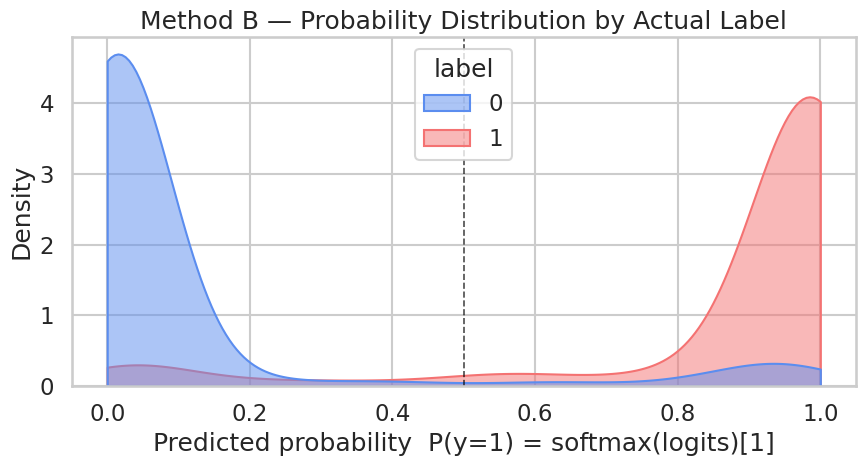

In [13]:
sns.set_theme(style="whitegrid", context="talk")

df = pd.DataFrame({"prob": probs, "logit": logits, "label": labels})
PAL = {0: "#5B8DEF", 1: "#F47272"}

fig, ax = plt.subplots(figsize=(9, 5))
sns.kdeplot(
    data=df, x="prob", hue="label",
    fill=True, common_norm=False, alpha=0.5,
    palette=PAL, clip=(0, 1), ax=ax,
)
ax.axvline(0.5, color="black", lw=1.2, ls="--", alpha=0.7)
ax.set_title("Method B — Probability Distribution by Actual Label")
ax.set_xlabel("Predicted probability  P(y=1) = softmax(logits)[1]")
ax.set_ylabel("Density")
plt.tight_layout()
plt.show()

### 4-2. 보조 그림 — $z = z_1 - z_0$ 의 logit 공간 분포

방식 B는 logit이 2차원 $(z_0, z_1)$ 이라 단순한 logit 공간 그림이 안 그려집니다. 그래서 **방식 A와 같은 1차원 logit 좌표로 환산** ($z = z_1 - z_0$) 해서 그립니다 — 이러면 결정 경계는 $z=0$, 의미는 $\sigma(z)=p_1$ 로 방식 A와 정확히 같아집니다.

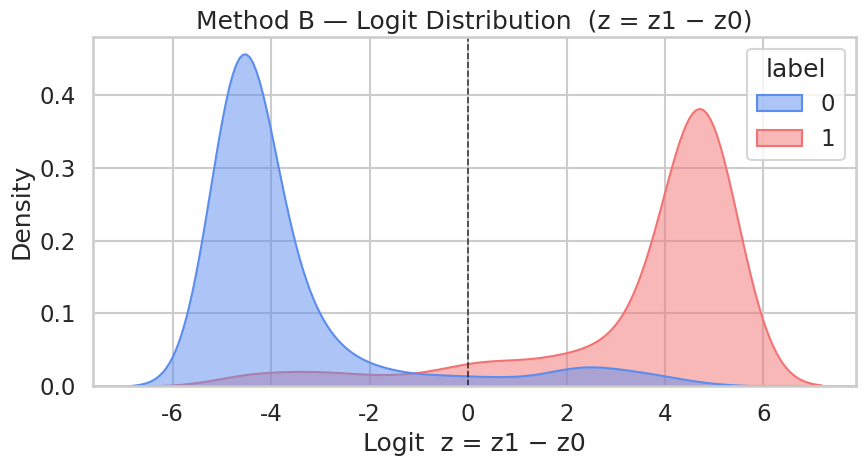

In [14]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.kdeplot(
    data=df, x="logit", hue="label",
    fill=True, common_norm=False, alpha=0.5,
    palette=PAL, ax=ax,
)
ax.axvline(0.0, color="black", lw=1.2, ls="--", alpha=0.7)
ax.set_title("Method B — Logit Distribution  (z = z1 − z0)")
ax.set_xlabel("Logit  z = z1 − z0")
ax.set_ylabel("Density")
plt.tight_layout()
plt.show()

**여기까지 정리** — 4-1과 4-2의 그림은 Ch 10의 것과 *모양* 이 거의 같아야 합니다. 봉우리 높이나 위치가 미세하게 다를 순 있어도, 양 끝 압착 / 가운데 헷갈림 영역 / 결정 경계 자리 같은 *큰 그림* 은 동일. 이게 두 방식 동등성의 *시각적* 증거.

In [15]:
# 상세 분류 리포트
print(classification_report(
    labels, probs_full.argmax(axis=1),
    target_names=["negative", "positive"],
    digits=4,
))

              precision    recall  f1-score   support

    negative     0.9188    0.9145    0.9167       433
    positive     0.9008    0.9057    0.9032       371

    accuracy                         0.9104       804
   macro avg     0.9098    0.9101    0.9099       804
weighted avg     0.9105    0.9104    0.9105       804



## 5. 🛠️ 클라이맥스 — 방식 A 를 *이 노트북 안에서* 다시 학습해 비교

이전 챕터(Ch 10)의 결과 파일에 의존하지 않도록, 같은 데이터·같은 hyperparams·같은 seed로 방식 A를 *바로 여기서* 한 번 더 학습합니다. 변하는 것은 **모델 셋업과 라벨 형식뿐** (Ch 10에서 본 그대로):

| 셋업 | 방식 B (§3-4에서 학습) | 방식 A (지금 inline 재학습) |
|---|---|---|
| `num_labels` | 2 | **1** |
| `problem_type` | `single_label_classification` | **`multi_label_classification`** |
| 라벨 형식 | int 스칼라 (`0` / `1`) | **길이 1 multi-hot float (`[0.0]` / `[1.0]`)** |
| 학습 hyperparams | (epoch=2, lr=2e-5, seed=42 …) | **그대로** |

T4 기준 추가 ~8분. 학습이 끝나면 같은 eval 셋의 $p_A^{(i)}$ 와 §4에서 구한 $p_B^{(i)}$ 를 1,000개 점으로 비교할 수 있게 됩니다.

In [16]:
# 방식 A용 라벨 변환 — int 0/1 → 길이 1 multi-hot float [0.0]/[1.0]
def to_method_a_labels(batch):
    batch["labels"] = [[float(l)] for l in batch["labels"]]
    return batch

# 텍스트·attention_mask는 그대로, labels만 바꿔서 새 데이터셋
train_tok_A = train_tok.map(to_method_a_labels, batched=True)
eval_tok_A  = eval_tok.map(to_method_a_labels,  batched=True)

print(f"Method A first sample label: {train_tok_A[0]['labels']}  (length-1 float vector)")
print(f"Method B first sample label: {train_tok[0]['labels']}    (int scalar)")

Map:   0%|          | 0/4040 [00:00<?, ? examples/s]

Map:   0%|          | 0/804 [00:00<?, ? examples/s]

Method A first sample label: [1.0]  (length-1 float vector)
Method B first sample label: 1    (int scalar)


In [17]:
# 방식 A 모델 — Ch 10과 동일 셋업
model_A = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=1,
    problem_type="multi_label_classification",
)

def compute_metrics_A(eval_pred):
    logits, lbl = eval_pred
    logits = logits.flatten()
    lbl    = lbl.flatten().astype(int)
    p_hat  = 1.0 / (1.0 + np.exp(-logits))
    preds  = (p_hat >= 0.5).astype(int)
    p, r, f1, _ = precision_recall_fscore_support(lbl, preds, average="binary", zero_division=0)
    return {
        "accuracy":  float(accuracy_score(lbl, preds)),
        "precision": float(p),
        "recall":    float(r),
        "f1":        float(f1),
        "auc":       float(roc_auc_score(lbl, p_hat)),
    }

print(f"Method A classifier:    {model_A.classifier}")
print(f"Method A problem_type:  {model_A.config.problem_type}")

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Method A classifier:    Linear(in_features=768, out_features=1, bias=True)
Method A problem_type:  multi_label_classification


In [18]:
# 방식 A 학습 — Ch 10과 동일한 hyperparams (방식 B와도 동일)
training_args_A = TrainingArguments(
    output_dir="./ch11_method_a_output",
    num_train_epochs=2,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    learning_rate=2e-5,
    fp16=True,
    eval_strategy="epoch",
    logging_steps=50,
    save_strategy="no",
    report_to="none",
    seed=42,
)

trainer_A = Trainer(
    model=model_A,
    args=training_args_A,
    train_dataset=train_tok_A,
    eval_dataset=eval_tok_A,
    processing_class=tokenizer,
    compute_metrics=compute_metrics_A,
)

train_result_A = trainer_A.train()
print(f"\nMethod A training done — train loss: {train_result_A.training_loss:.4f}")

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1,Auc
1,0.245630,0.248752,0.906716,0.893617,0.905660,0.899598,0.968371
2,0.162265,0.281090,0.905473,0.904110,0.889488,0.896739,0.966261



Method A training done — train loss: 0.2588


In [19]:
# 방식 A 예측 추출
preds_A_out = trainer_A.predict(eval_tok_A)
logits_A    = preds_A_out.predictions.flatten()
probs_A     = 1.0 / (1.0 + np.exp(-logits_A))
labels_A    = preds_A_out.label_ids.flatten().astype(int)

# eval_tok과 eval_tok_A는 라벨 형식만 다르고 샘플 순서는 동일 → 라벨 일치해야 함
assert (labels_A == labels).all(), "Sample order mismatch — check eval_tok / eval_tok_A derivation"

eval_metrics_A = trainer_A.evaluate()
print("Method A evaluation:")
for k, v in eval_metrics_A.items():
    if k.startswith("eval_") and isinstance(v, float):
        print(f"  {k:>20}: {v:.4f}")

Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1,Auc
0.162265,0.281090,2,0.905473,0.904110,0.889488,0.896739,0.966261


Method A evaluation:
             eval_loss: 0.2811
         eval_accuracy: 0.9055
        eval_precision: 0.9041
           eval_recall: 0.8895
               eval_f1: 0.8967
              eval_auc: 0.9663


### 5-1. 두 방식의 metric 표 비교

같은 데이터에 같은 모델 본체로 학습했고 hyperparams도 같으니, accuracy/F1/AUC 같은 평가 지표가 *거의 같은* 값이어야 합니다. 차이가 있다면 random init과 dropout 같은 *학습 경로* 차이에서 옵니다.

In [20]:
metrics_A = {k.replace("eval_", ""): v for k, v in eval_metrics_A.items()
             if k.startswith("eval_") and isinstance(v, float)}
metrics_B = {k.replace("eval_", ""): v for k, v in eval_metrics.items()
             if k.startswith("eval_") and isinstance(v, float)}

common = [k for k in metrics_A if k in metrics_B]
cmp = pd.DataFrame({
    "metric":                  common,
    "method A (sigmoid+BCE)":  [metrics_A[k] for k in common],
    "method B (softmax+CE)":   [metrics_B[k] for k in common],
})
cmp["|A-B|"] = (cmp["method A (sigmoid+BCE)"] - cmp["method B (softmax+CE)"]).abs()
print(cmp.round(4).to_string(index=False))

   metric  method A (sigmoid+BCE)  method B (softmax+CE)  |A-B|
     loss                  0.2811                 0.2716 0.0094
 accuracy                  0.9055                 0.9104 0.0050
precision                  0.9041                 0.9008 0.0033
   recall                  0.8895                 0.9057 0.0162
       f1                  0.8967                 0.9032 0.0065
      auc                  0.9663                 0.9671 0.0009


### 5-2. 샘플 단위 확률 비교 — scatter plot

x축 = 방식 A의 $p_A$, y축 = 방식 B의 $p_B$. 점 색은 정답 라벨.

**완전히 동등하면 모든 점이 $y = x$ 직선 위**. 실제로는 random init·dropout·optimizer 비결정성 때문에 약간 흩어지지만, 직선에서 크게 벗어나면 안 됩니다.

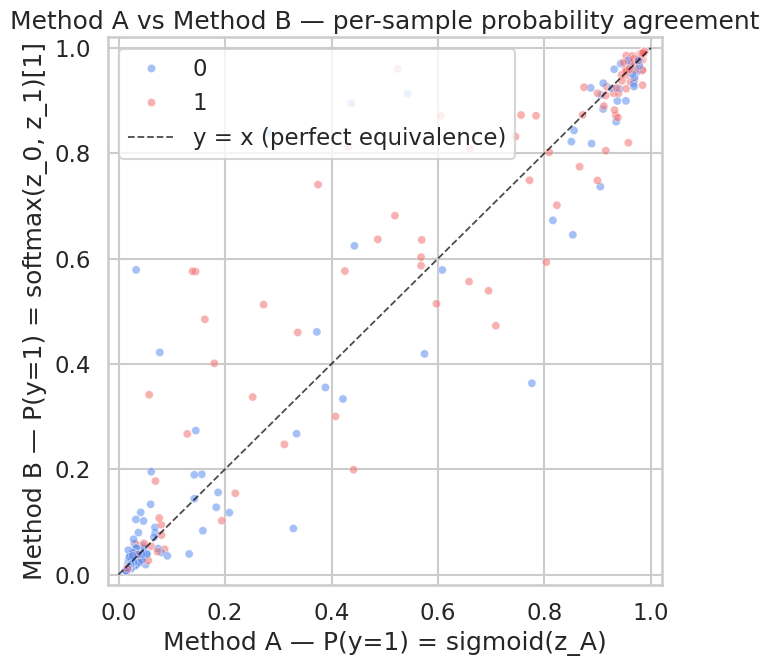

Pearson corr:        0.9904  (1.0 = perfect equivalence)
Mean abs diff |A-B|: 0.0220


In [21]:
df_cmp = pd.DataFrame({
    "prob_A": probs_A,
    "prob_B": probs,
    "label":  labels.astype(int),
})

fig, ax = plt.subplots(figsize=(7, 7))
sns.scatterplot(
    data=df_cmp, x="prob_A", y="prob_B", hue="label",
    palette={0: "#5B8DEF", 1: "#F47272"}, alpha=0.55, s=35, ax=ax,
)
ax.plot([0, 1], [0, 1], color="black", lw=1.3, ls="--", alpha=0.7,
        label="y = x (perfect equivalence)")
ax.set_xlim(-0.02, 1.02); ax.set_ylim(-0.02, 1.02)
ax.set_xlabel("Method A — P(y=1) = sigmoid(z_A)")
ax.set_ylabel("Method B — P(y=1) = softmax(z_0, z_1)[1]")
ax.set_title("Method A vs Method B — per-sample probability agreement")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

corr = float(np.corrcoef(probs_A, probs)[0, 1])
mae  = float(np.abs(probs_A - probs).mean())
print(f"Pearson corr:        {corr:.4f}  (1.0 = perfect equivalence)")
print(f"Mean abs diff |A-B|: {mae:.4f}")

**해석**

- **상관계수가 0.99 이상**, **평균 절대 차가 0.05 이하** 면 두 방식이 사실상 같은 함수를 학습했다고 봐도 됩니다.
- 만약 점들이 *체계적으로* 직선 한쪽으로 치우친다면 → 한 방식이 다른 방식보다 일관되게 더 자신 있게 / 더 보수적으로 예측하고 있다는 뜻. seed를 여러 개 시도해 평균내면 보통 사라집니다.
- 점들이 직선 *주변에 무작위로* 흩어져 있으면 → 단순 학습 경로 차이. 학습량을 늘리거나 더 큰 데이터에서 학습하면 줄어듭니다.

### 5-3. 예측 일치율 (threshold 0.5)

확률을 0/1 예측으로 떨어뜨린 뒤 두 방식의 예측이 얼마나 일치하는지 봅니다. 일치율이 95% 이상이면 *실질적으로* 같은 분류기로 봐도 됩니다.

In [22]:
pred_A = (probs_A >= 0.5).astype(int)
pred_B = (probs   >= 0.5).astype(int)

agree         = (pred_A == pred_B).mean()
both_correct  = ((pred_A == labels) & (pred_B == labels)).mean()
only_A_right  = ((pred_A == labels) & (pred_B != labels)).mean()
only_B_right  = ((pred_A != labels) & (pred_B == labels)).mean()
both_wrong    = ((pred_A != labels) & (pred_B != labels)).mean()

print(f"Agreement rate (A vs B predictions): {agree:.1%}")
print()
print(f"Prediction quadrants:")
print(f"  both correct:           {both_correct:.1%}")
print(f"  only A correct (B wrong): {only_A_right:.1%}")
print(f"  only B correct (A wrong): {only_B_right:.1%}")
print(f"  both wrong:             {both_wrong:.1%}")

Agreement rate (A vs B predictions): 98.3%

Prediction quadrants:
  both correct:           89.9%
  only A correct (B wrong): 0.6%
  only B correct (A wrong): 1.1%
  both wrong:             8.3%


**여기까지 보고 결론** — 식으로 본 동등성 ($\sigma(z) = \mathrm{softmax}(z_0, z_1)[1]$ when $z = z_1 - z_0$)이 BERT에서도 그대로 성립합니다. 차이가 있어 봐야 random init / dropout 같은 *학습 경로 차이* 정도. 두 방식은 **수식이 다른 같은 모델**, 라이브러리·코드 컨벤션이 강요하는 표현 차이일 뿐입니다.

> **현장 가이드**: 새 BERT 분류 task를 시작할 때는 *방식 B (softmax+CE)* 가 표준 — `num_labels=K`, `problem_type="single_label_classification"` 만 두면 끝. 방식 A는 *binary 라벨이 multi-label 형식으로 들어오는 시나리오* (예: 이진 라벨이 여러 헤드 중 하나로 끼어 있는 경우)에서만 의식적으로 사용합니다.

## 📦 이번 챕터에 등장한 라이브러리·함수

| 이름 | 한 줄 설명 | 다음 챕터에서 |
|---|---|---|
| `AutoModelForSequenceClassification(num_labels=2, problem_type="single_label_classification")` | BERT 표준 분류 셋업 | Ch 12 (multi-class)에서 `num_labels=5` 만 바꿔 그대로 |
| `id2label` / `label2id` | config에 사람이 읽는 라벨 이름 등록 (Ch 7 appendix에서 본 것) | 분류 챕터마다 권장 |
| `numpy.exp / sum` 으로 직접 softmax | 안정 softmax 수동 구현 (`max` 빼고 정규화) | Ch 12·13에서 multi-class 확률 추출에 동일 패턴 |
| `seaborn.scatterplot(hue=, alpha=)` | 두 모델의 sample-level prediction 비교에 적합 | Ch 14 auxiliary loss 비교에서 다시 사용 |
| `numpy.corrcoef`, `numpy.abs(a-b).mean()` | 두 분포의 동등성을 수치로 정량화 | 모델 비교가 필요한 챕터마다 |

## 🎯 체크포인트 질문

1. 방식 B의 출력 logit shape이 `(B, 2)` 인데, 방식 A와 비교할 1차원 logit을 어떻게 만드나요? 왜 그게 정당한가요?
2. `problem_type="single_label_classification"` 과 `"multi_label_classification"` 의 차이를 한 줄로 설명한다면?
3. 방식 A와 방식 B의 *학습된 가중치* 가 똑같지 않은데도 *최종 확률* 이 거의 같은 이유는?
4. scatter plot에서 점들이 $y=x$ 직선에서 *체계적으로* 위 또는 아래로 치우친다면 무엇을 의심해야 하나요?

## ❓ FAQ

### Q1. (실무) BERT 이진 분류는 그냥 방식 B 쓰면 되는 거죠?

네, 99%의 경우 방식 B가 답입니다.

```python
model = AutoModelForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=2,
    problem_type="single_label_classification",  # 사실 num_labels>=2면 default
)
```

방식 A는 *이진 라벨이 multi-label 형식으로 들어와야 하는 특수 시나리오* (예: K개 라벨 중 하나만 binary로 처리하고 나머지는 다른 헤드에 붙이는 구조)에서만 의식적으로 씁니다. 일반 binary classification은 그냥 B.

### Q2. (이론) Ch 4의 sklearn 동등성 시연(`predict_proba` 일치)과 Ch 11의 BERT 동등성 시연(scatter plot) 의 차이는?

| | Ch 4 (sklearn) | Ch 11 (BERT) |
|---|---|---|
| 두 모델이 *같은 가중치* 를 학습? | **사실상 그렇다** — 작은 모델이라 두 방식이 같은 최적해로 수렴 | 아니다 — 67M 파라미터 중 일부가 random init 차이로 다른 곳에 정착 |
| `predict_proba` 가 정확히 같은가? | **거의 일치** (소수점 4-5자리까지) | *근사적으로* 일치 (Pearson 0.99+, MAE 0.01-0.05) |
| 차이의 출처 | sklearn 옵티마이저 수렴 정밀도 | random init + dropout + GPU 비결정성 |

수학적 동등성($\sigma(z) = \mathrm{softmax}(z_0,z_1)[1]$ where $z=z_1-z_0$)은 두 경우 모두 성립합니다. 구현 차원의 노이즈 양이 다를 뿐.

### Q3. (실무) `compute_metrics` 안의 softmax를 직접 구현하지 말고 `torch.softmax` 쓰면 안 되나요?

써도 됩니다. 단, `compute_metrics` 가 받는 `logits` 는 *numpy 배열* 이라 `torch.from_numpy` 로 한 번 감싸야 합니다.

```python
import torch
probs_full = torch.softmax(torch.from_numpy(logits), dim=-1).numpy()
```

이 챕터에선 *softmax가 어떻게 동작하는지* 노출하기 위해 `np.exp / sum` 으로 직접 짰습니다 — `max` 빼서 안정화하는 부분이 곧 PyTorch 내부 구현과 동일한 트릭입니다.

### Q4. (이론) 방식 A·B 가 sklearn 안에선 사실상 같은 모델이라고 했는데, 그러면 BERT 에서도 두 학습 결과가 같아야 하지 않나요?

sklearn 의 binary `LogisticRegression()` 은 modern 기본 동작이 *softmax+CE* 든 *sigmoid+BCE* 든 동일한 형태로 학습 (Ch 4 FAQ Q4 — `coef_.shape=(1, V)` 로 collapse). 즉 sklearn 에선 두 방식이 거의 *수치적 등가*. BERT 에선 그렇지 않은 이유는 다음입니다.

sklearn에서는 두 *방식* 의 차이가 BERT보다 훨씬 작습니다. 이유는:

1. **모델 크기**: sklearn LogReg는 ~10K 파라미터. BERT는 67M. 작은 모델이 큰 모델보다 *유일한 최적해* 로 수렴하기 쉽습니다.
2. **무작위성 원천**: sklearn LogReg는 `liblinear`/`lbfgs` 같은 결정론적 옵티마이저 기본. BERT는 SGD 기반 + GPU + dropout 으로 *원천적으로* 비결정적.
3. **데이터 표현**: sklearn TF-IDF는 sparse fixed feature. BERT는 매 backprop마다 hidden state도 업데이트.

그래서 Ch 4에서는 두 sklearn 모델의 `predict_proba` 가 *소수점 4-5 자리* 까지 같았고, Ch 11에서는 *소수점 1-2 자리* 수준에서 같습니다.

### Q5. (실무) 학습된 모델을 저장·로드할 때 두 방식 모델은 호환되나요?

**아니요, 분류 헤드 shape이 달라서 직접 호환되지 않습니다.**

- 방식 A: `classifier.weight.shape = (1, 768)`, `classifier.bias.shape = (1,)`
- 방식 B: `classifier.weight.shape = (2, 768)`, `classifier.bias.shape = (2,)`

`from_pretrained` 로 다른 방식의 체크포인트를 로드하면 분류 헤드를 *새로 초기화* 한다는 경고가 뜹니다 (DistilBERT body는 그대로 로드됨). 따라서 두 방식 사이의 변환은 *처음부터 다시 학습* 이 정확합니다.

만약 **같은 표현력을 유지하면서** 변환하고 싶다면, 방식 A의 $w_A, b_A$ 로부터 방식 B의 헤드를 다음과 같이 만들 수 있습니다 — 한쪽 클래스 logit을 0으로 고정하면 됩니다.

```python
# 방식 A → 방식 B (수학적 동등 변환)
W_A = model_A.classifier.weight    # shape (1, 768)
b_A = model_A.classifier.bias      # shape (1,)

W_B = torch.cat([torch.zeros_like(W_A), W_A], dim=0)  # (2, 768) — 0번 클래스는 0 logit
b_B = torch.cat([torch.zeros_like(b_A), b_A], dim=0)  # (2,)
```

이러면 $z_1 - z_0 = (W_A x + b_A) - 0 = z_A$ 가 정확히 일치합니다. 실무에선 거의 안 쓰지만 *수학적 동등성* 의 구체적 모습을 보여주는 좋은 예시.

### Q6. (실무) `id2label` / `label2id` 는 꼭 등록해야 하나요?

학습·평가 자체에는 영향 없지만 **추론 시 편리** 합니다.

```python
pipe = pipeline("text-classification", model=model, tokenizer=tokenizer)
pipe("Great food!")
# [{'label': 'POSITIVE', 'score': 0.99}]   ← id2label 등록했으면 사람이 읽는 라벨
# [{'label': 'LABEL_1', 'score': 0.99}]    ← 등록 안 했으면 LABEL_0/1 같은 기본
```

또 `model.config.id2label` 이 huggingface hub에 모델을 올릴 때 widget 라벨 표시용으로 쓰입니다. 한 줄 추가로 큰 이득이라 항상 등록하는 게 좋습니다.

## 🚀 삽질 코너 (선택)

다음 코드를 돌려보면 어떤 에러가 날까요?

```python
# 라벨을 길이 1 multi-hot 벡터로 두고 num_labels=2 모델에 학습 시도 (Ch 10 라벨 형식 ↔ Ch 11 모델)
def tokenize_wrong(batch):
    out = tokenizer(batch["text"], truncation=True, max_length=128)
    out["labels"] = [[float(b)] for b in batch["binary"]]   # ← 잘못: Ch 10 형식
    return out
```

힌트: `CrossEntropyLoss` 가 받는 라벨은 *int 인덱스 텐서* (shape `(B,)`)인데 위 코드는 *float 2차원 텐서* (shape `(B, 1)`)을 넘깁니다. 텐서 dtype과 shape을 동시에 틀린 케이스라 메시지가 다소 길게 나올 수 있습니다.

## 다음 챕터 예고

**Chapter 12. BERT Multi-class — Yelp 5클래스**

- Yelp 별점 1-5 를 그대로 5클래스 분류로 (Ch 5의 sklearn 버전을 BERT로)
- `num_labels=5`, `problem_type="single_label_classification"` (Ch 11과 같은 표준 셋업, K만 2 → 5)
- Activation은 그대로 softmax, Loss는 그대로 `CrossEntropyLoss`
- **변하는 축은 *task* 하나** — Loss·activation·문제 셋업이 동일. K=2가 K=5로 자연스럽게 일반화되는 모습 확인

> **Phase 1 흐름 정리 (Ch 7 - Ch 14)**: BERT (영어) 위에서 Regression(9) → Binary 방식 A(10) → Binary 방식 B(11) → Multi-class(12) → Multi-label(13) → Auxiliary(14). 한 챕터에 한 축씩만 변합니다.